In [1]:
import sys
sys.path.insert(0, '../')

from src.load_data import PatientLoader
from src.process import NeuroFeatureExtractor

## Explore Data

In [2]:
from nilearn import plotting, image, masking

In [3]:
file_path = "../data/sub-1004"
loader = PatientLoader()
recording = loader.load(file_path)
extractor = NeuroFeatureExtractor(
    target_resolution=3,
    n_rois=200
)

Fetching Schaefer Atlas (200 ROIs)...


[fetch_atlas_schaefer_2018] Dataset found in /home/marcos/nilearn_data/schaefer_2018

In [7]:
# Make an average
time_series = extractor.extract_time_series(recording)

/home/marcos/marcos/master/Q2/NeuroImage/FinalProject/notebooks/../src/process.py:42: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = self.masker.fit_transform(resampled_img)


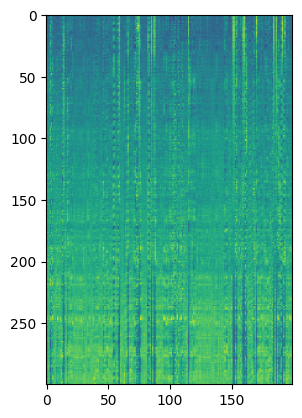

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(time_series)
plt.show()

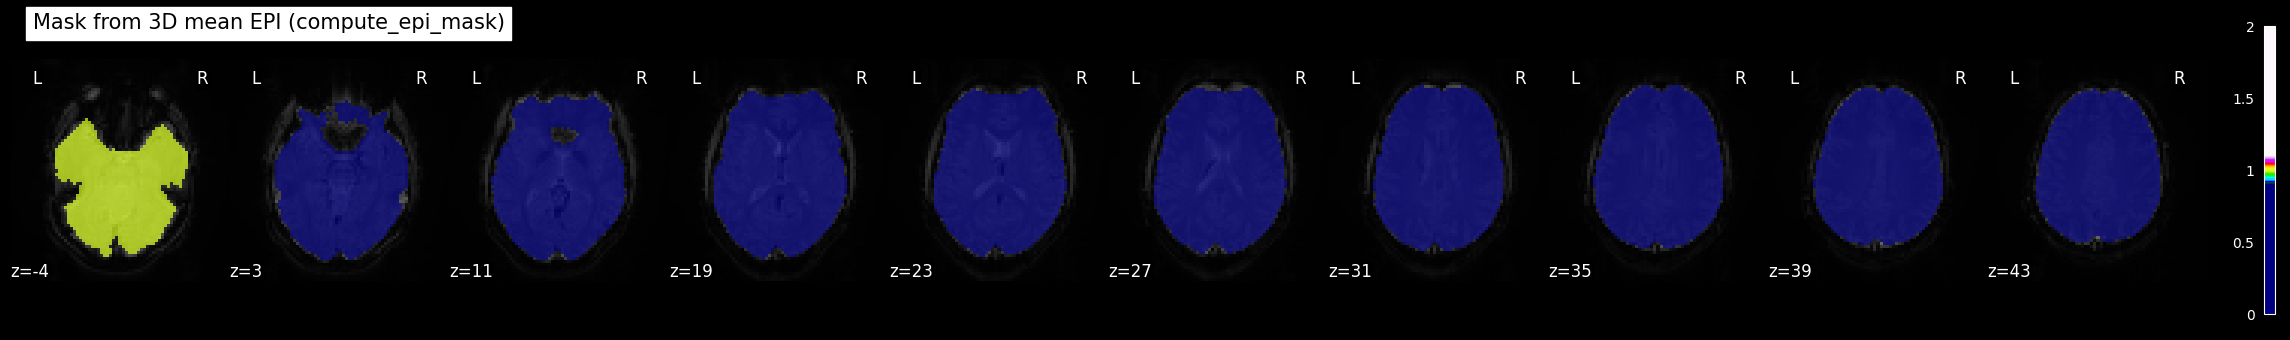

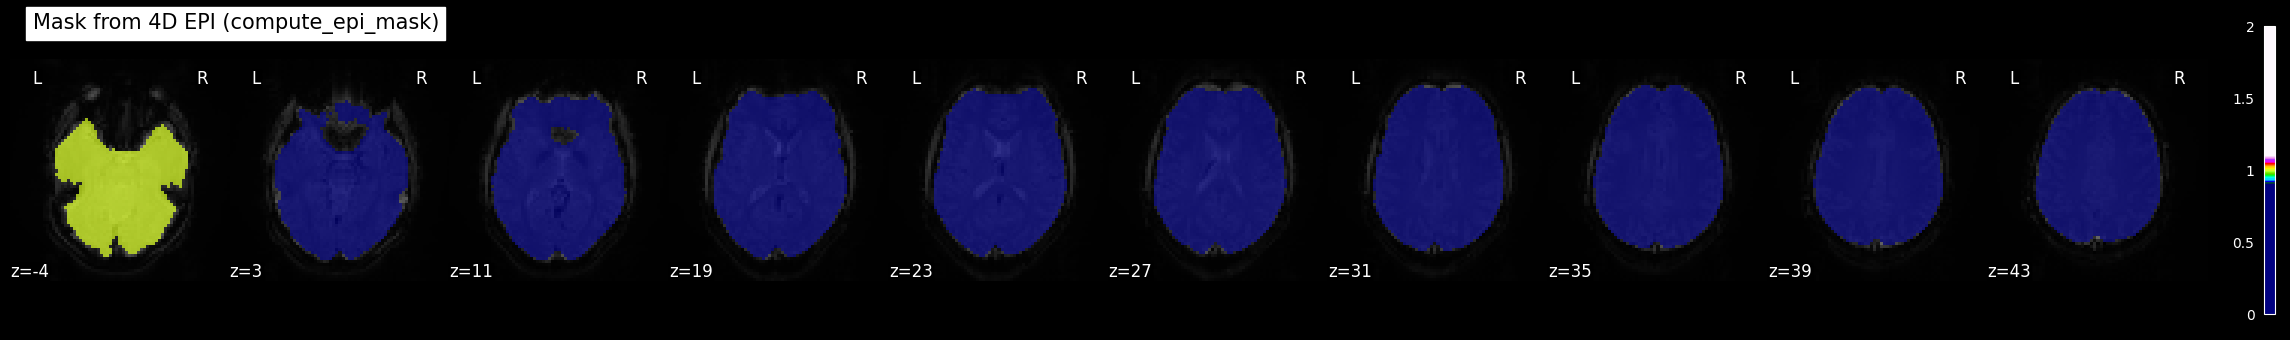

In [8]:
mean_img = image.mean_img(recording.func.img)
mask3d = masking.compute_epi_mask(mean_img)
mask4d = masking.compute_epi_mask(recording.func.img)

plotting.plot_roi(
    mask3d,
    bg_img=mean_img,
    title="Mask from 3D mean EPI (compute_epi_mask)",
    display_mode="z",
    cut_coords=10,
)
plotting.plot_roi(
    mask4d,
    bg_img=mean_img,
    title="Mask from 4D EPI (compute_epi_mask)",
    display_mode="z",
    cut_coords=10,
)

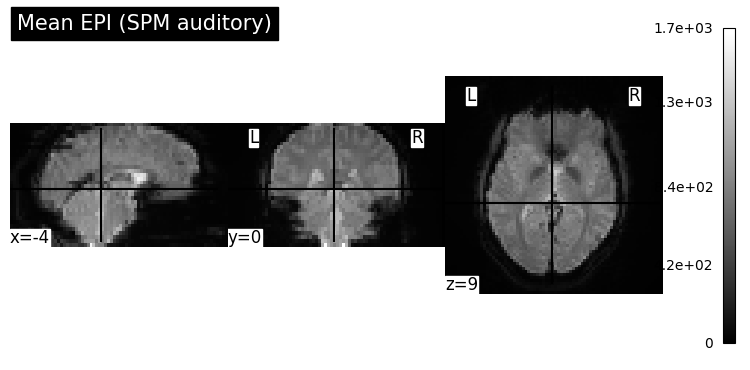

In [9]:
plotting.plot_img(mean_img, title="Mean EPI (SPM auditory)")

## **Get the atlas for regions feature extraction**

In [ ]:
from nilearn import datasets

def fetch_schaefer_atlas():
    # Fetch the Schaefer 200 parcels atlas with Yeo 7 or 17 networks
    atlas = datasets.fetch_atlas_schaefer_2018(
        n_rois=200, 
        yeo_networks=7, 
        resolution_mm=1
    )
    return atlas['maps'], atlas['labels']

maps, labels = fetch_schaefer_atlas()
plotting.plot_roi(maps, bg_img=mean_img, title="Schaefer Atlas (200 parcels, Yeo 7 networks)", display_mode="z", cut_coords=10)

OSError: Nilearn tried to store the dataset in the following directories, but: 
 -/home/marcos/nilearn_data/schaefer_2018 (name 'escape' is not defined)